### Compute NDVI, NDWI and NDBI indices for each year

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import rasterio
import numpy as np

from src.indices import batch_compute_indices
from src.config import ROOT

In [2]:
YEARS = [2016, 2022, 2025]

batch_compute_indices(
    ROOT / "data" / "processed" / "clipped",
    ROOT / "data" / "processed" / "indices",
    YEARS,
)


Processing 2016
  ✓ NDVI
  ✓ NDWI
  ✓ NDBI

Processing 2022
  ✓ NDVI
  ✓ NDWI
  ✓ NDBI

Processing 2025
  ✓ NDVI
  ✓ NDWI
  ✓ NDBI


Verify Output

In [3]:
sample = (ROOT / "data" / "processed" / "indices" / "2022" / "NDVI.tif")

with rasterio.open(sample) as src:
    ndvi = src.read(1)

print("Min:", np.nanmin(ndvi))
print("Max:", np.nanmax(ndvi))
print("Mean:", np.nanmean(ndvi))

Min: -9999.0
Max: 0.81636727
Mean: -6257.8394


Visual Check

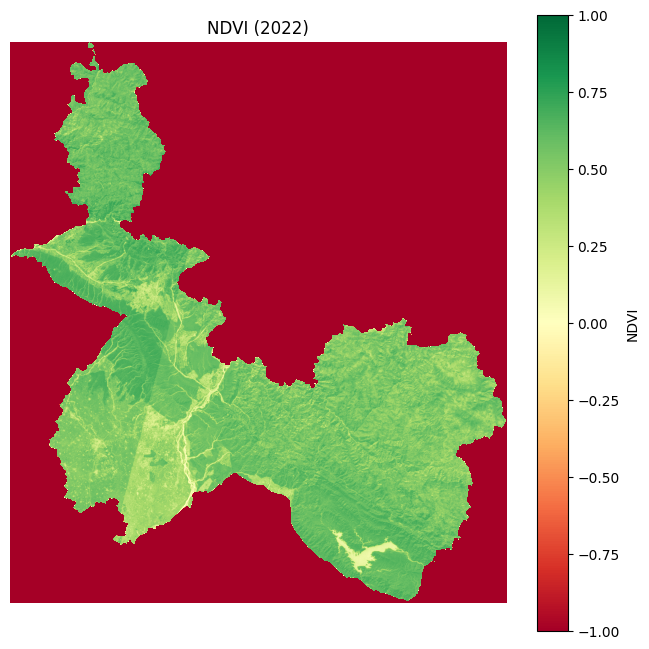

In [4]:
with rasterio.open(sample) as src:
    ndvi = src.read(1)

plt.figure(figsize=(8, 8))

plt.imshow(
    ndvi,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
)

plt.colorbar(label="NDVI")
plt.title("NDVI (2022)")
plt.axis("off")

plt.show()